# Substantia nigra scANVI training

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scarches.dataset.trvae.data_handling import remove_sparsity
import torch

import anndata
import scvi
import scanpy as sc
import wandb

from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning import Trainer

sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

scvi.settings.seed = 94705


%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

In [ ]:
data_dir = 'out/'

In [ ]:
## read data
adata = sc.read_h5ad(data_dir + 'human_filtered_meta.h5ad')

In [7]:
reference_adata = adata
reference_adata = remove_sparsity(reference_adata)
if not reference_adata.raw:
    reference_adata.raw = reference_adata

In [10]:
# Fill the counts layer with the raw counts
reference_adata.layers['counts'] = reference_adata.raw.X if reference_adata.raw else reference_adata.X

In [11]:
reference_adata.write_h5ad(data_dir + 'human_for_training.h5ad', compression='gzip')

In [5]:
reference_adata = sc.read_h5ad(data_dir + 'human_for_training.h5ad')

In [6]:
sc.pp.normalize_total(reference_adata)
sc.pp.log1p(reference_adata)

In [ ]:
reference_adata.obs['donor_id']

In [8]:
condition_key = 'donor_id'

In [ ]:
reference_adata.obs['subtype']

In [10]:
cell_type_key = 'subtype'

In [11]:
reference_adata.obs["labels_scanvi"] = reference_adata.obs[cell_type_key].values
reference_adata.obs["batches_scvi"] = reference_adata.obs[condition_key].values

In [12]:
sc.pp.highly_variable_genes(
    reference_adata,
    n_top_genes=2000,
    batch_key='batches_scvi',
    subset=True)

In [13]:
reference_adata.X = reference_adata.raw[:, reference_adata.var_names].X

In [14]:
scvi.model.SCVI.setup_anndata(reference_adata, 
                              batch_key='batches_scvi', # Use a batch key if we have batches
                              layer="counts")

In [15]:
import os

In [16]:
try:
    nvidia_pid = ! nvidia-smi -q | grep 'Process ID' 
    nvidia_pid = nvidia_pid[0].split(':')[1].strip()

    if os.getpid() != int(nvidia_pid):
        print(f'Killing: {nvidia_pid}')
        ! kill {nvidia_pid}
except:
    print("GPU wasn't locked")
    pass

GPU wasn't locked


In [18]:
full_dataset_name = 'Macosko'

In [ ]:
arches_params = dict(
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)

vae_ref = scvi.model.SCVI(
    reference_adata,
    **arches_params
)

project_name = f'scVI__{full_dataset_name}__{condition_key}' if condition_key else f'scVI__{full_dataset_name}'
scvi_wandb_logger = WandbLogger(project=project_name)
vae_ref.train(logger=scvi_wandb_logger, early_stopping=True, train_size=0.8, check_val_every_n_epoch=1)

In [ ]:
wandb.finish()

In [ ]:
# unlabeled category does not exist in adata.obs[labels_key]
# so all cells are treated as labeled
vae_ref_scan = scvi.model.SCANVI.from_scvi_model(
    vae_ref,
    unlabeled_category="Unknown",
    labels_key="labels_scanvi",
)

project_name = f'scANVI__{full_dataset_name}__{condition_key}' if condition_key else f'scANVI__{full_dataset_name}'
project_name += f'__{cell_type_key}'
scanvi_wandb_logger = WandbLogger(project=project_name)
logger_kwargs = {'logger': scanvi_wandb_logger, 'check_val_every_n_epoch': 1}
vae_ref_scan.train(max_epochs=100, n_samples_per_label=100, early_stopping=True, train_size=0.8, **logger_kwargs)

In [ ]:
wandb.finish()

In [23]:
reference_adata.obsm["X_scANVI"] = vae_ref_scan.get_latent_representation()
sc.pp.neighbors(reference_adata, use_rep="X_scANVI")
sc.tl.leiden(reference_adata)
sc.tl.umap(reference_adata)

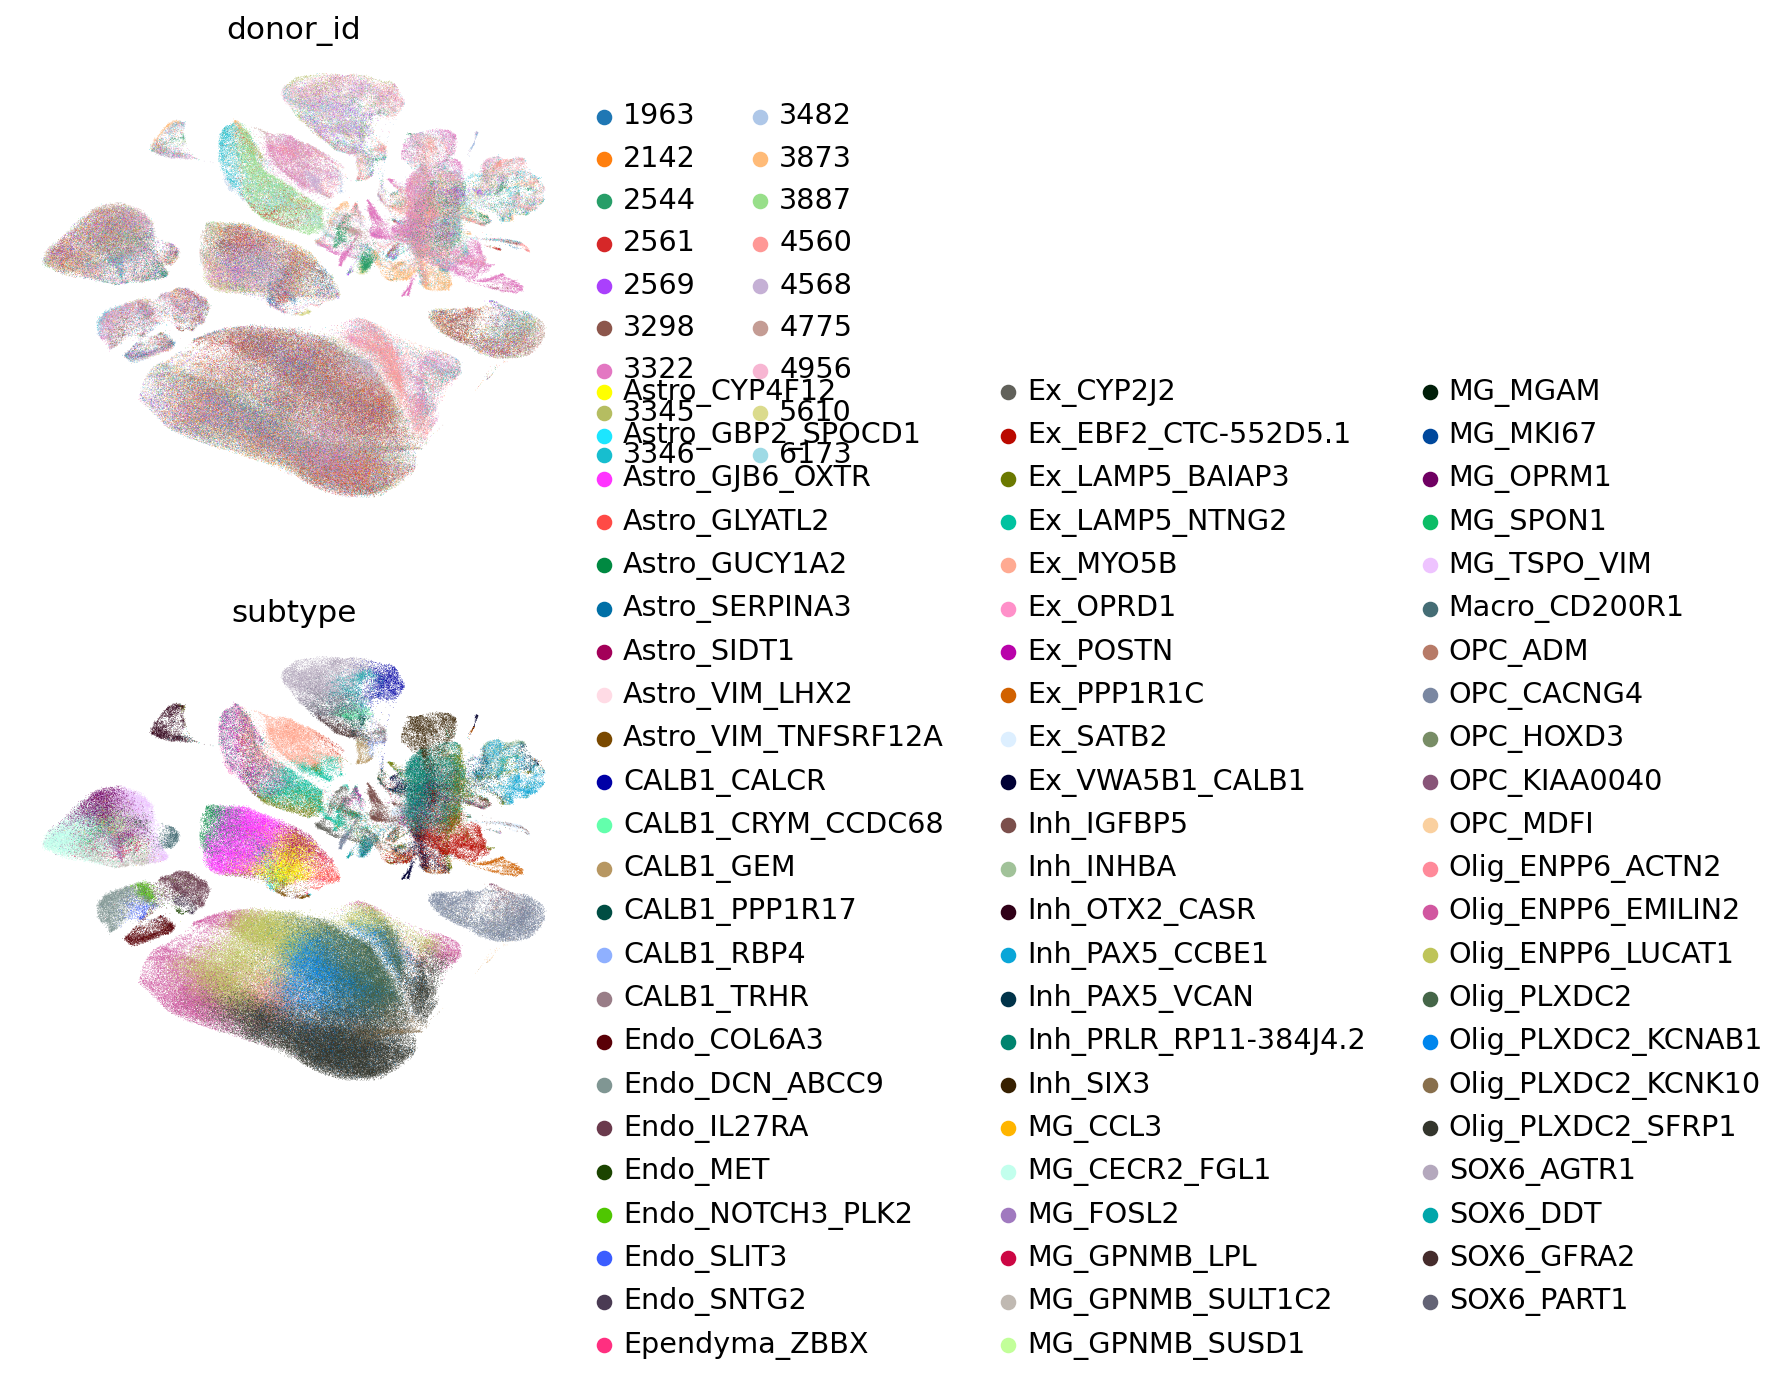

In [24]:
sc.pl.umap(
    reference_adata,
    color=[condition_key, cell_type_key],
    frameon=False,
    ncols=1,
)

In [25]:
from pathlib import Path 

In [26]:
models_base_dir = Path('out/scANVI_Models_SN/')

In [31]:
model_dir_path = models_base_dir / f""

In [32]:
! mkdir -p {model_dir_path}

In [33]:
vae_ref_scan.save(model_dir_path, overwrite=True)

In [34]:
reference_adata.write_h5ad(f'{model_dir_path}/{full_dataset_name}_post_train.h5ad', compression='gzip')

In [35]:
print(model_dir_path)

/staging/leuven/stg_00002/lcb/jdeman/CZI/Kamath_Macosko/scANVI_Models


In [36]:
! ls -la {model_dir_path}

total 3733320
drwxrwx---+ 3 vsc34498 vsc34498       4096 Oct 10 16:11 .
drwxrwx---+ 7 vsc34498 vsc34498       4096 Oct  4 16:22 ..
drwxrwx---+ 2 vsc34498 vsc34498       4096 Oct  4 16:50 .ipynb_checkpoints
-rw-rw----+ 1 vsc34498 vsc34498 3816850969 Oct 10 16:23 Macosko_post_train.h5ad
-rw-rw----+ 1 vsc34498 vsc34498        169 Oct  4 17:00 error_file
-rw-rw----+ 1 vsc34498 vsc34498        397 Oct  4 17:00 log_file
-rw-rw----+ 1 vsc34498 vsc34498       4059 Oct  4 16:38 macosko_scanvi.py
-rw-rw----+ 1 vsc34498 vsc34498        654 Oct  4 17:01 macosko_scanvi.sh
-rw-rw----+ 1 vsc34498 vsc34498    9331477 Oct 10 16:11 model.pt


In [37]:
!chmod a+rX -R {models_base_dir}

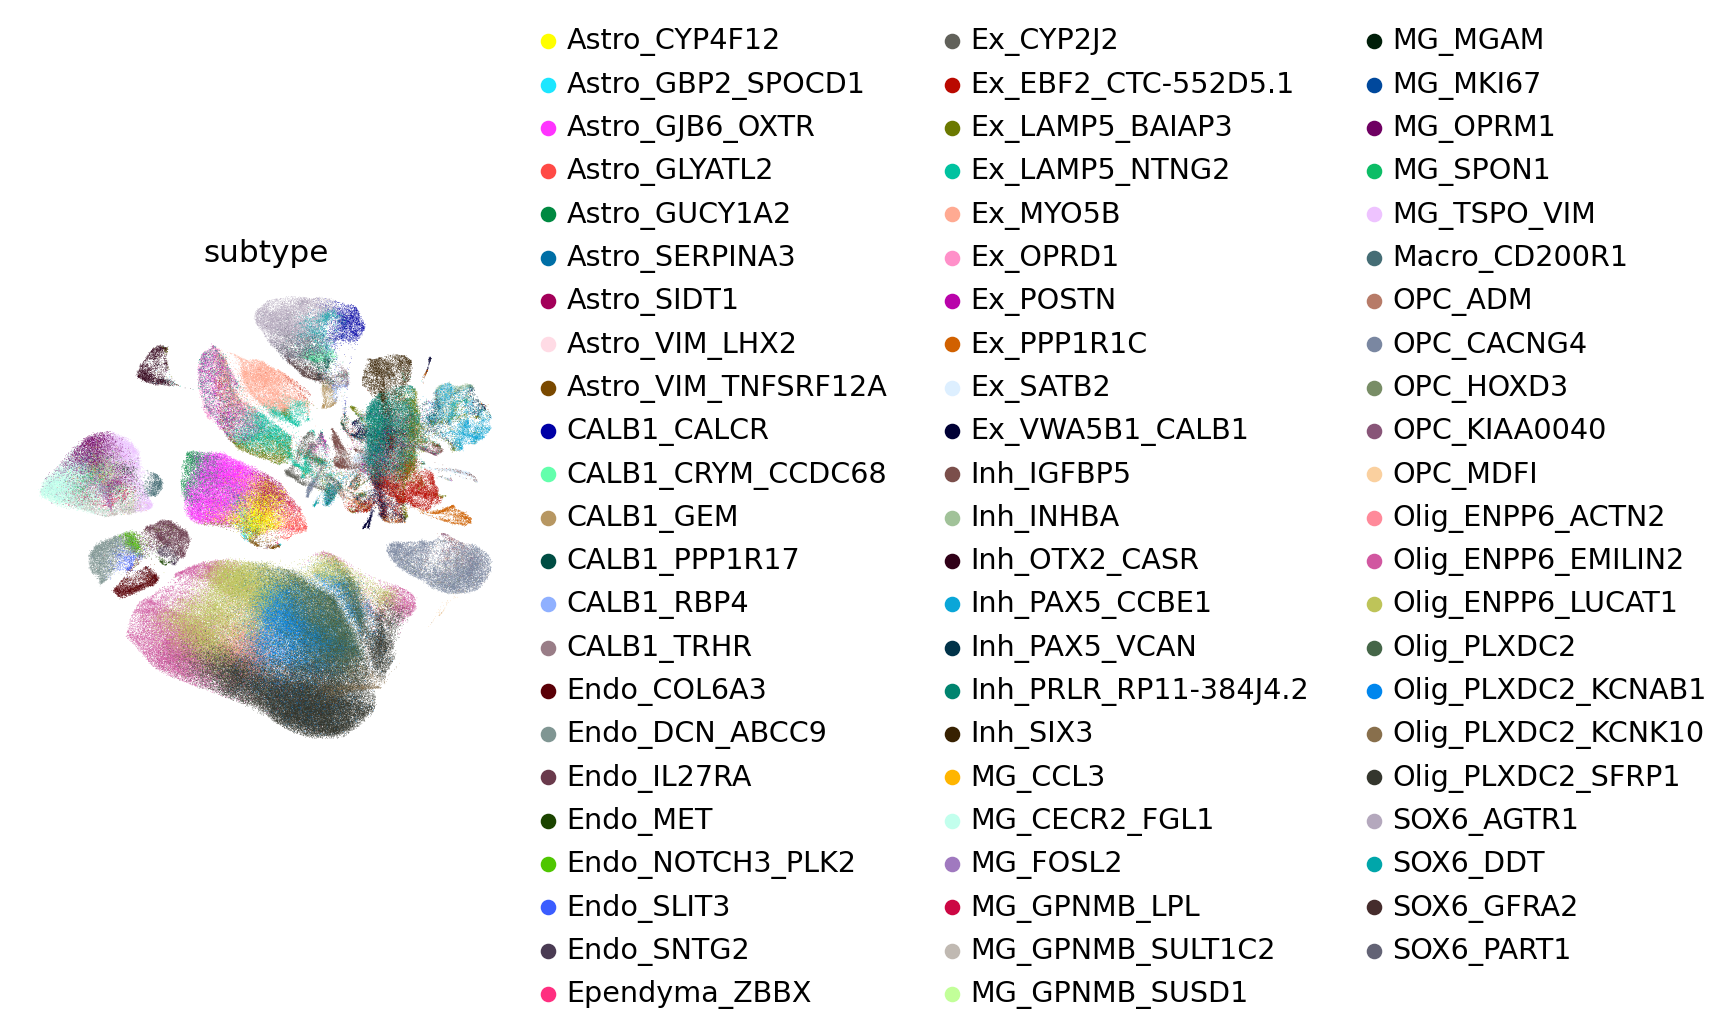

In [38]:
sc.pl.umap(
    reference_adata,
    color=[cell_type_key],
    frameon=False,
    ncols=1,
)